# Chapter 12 — Is There Actually One Thing Here?

## Book linkage

- **Current chapter:** [`12-is-there-actually-one-thing-here.md`](../content/books/digital-life/12-is-there-actually-one-thing-here.md)
- **Claims supported:** DL-12-C01 .. DL-12-C03 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:** original book Chapter 22 ("Is the Crystal a Thing or a Flow?"), two-version chain
  `research/digital-life/ch22-predictive-coherence-v1` (predictive-coherence screen) and
  `ch22-causal-boundary-coherence-v2` (causal-boundary-localization test). Scripts
  `ch22_digital_crystal_predictive_coherence_v1.py`, `ch22_digital_crystal_causal_boundary_coherence_v2.py`.
- **Legacy notebook:** `notebooks_original/22-is-the-crystal-a-thing-or-a-flow.ipynb` -- noted in the
  migration audit as a **pure-audit notebook with no live computation** (it loads precomputed JSON from the
  archive and asserts against it).

This notebook is the required upgrade past that pure-audit pattern: it genuinely runs the predictive-
coherence ridge regression and the matched-intervention causal-localization test at reduced scale, using a
new shared module, `_shared/crystal_boundary.py`, built on top of `_shared/crystal_evaluation_budget.py`'s
finite-evaluation-budget substrate (Chapter 11) -- matching the book's own frozen substrate for this chapter
(`delta=0.08`, neutral budget `B=96`). It is an independent reconstruction, not a copy of the historical
scripts, which depend on the heavier Chapter 18 `ch18` material-state module this chapter's claims do not
need.


## Question

We have said "the crystal" for five chapters without testing whether the noun refers to anything. This
chapter tests two operationally defined ways a spatial region might earn causal privilege:

- **V1 -- predictive coherence screen:** does a candidate region's own recent process state contribute
  held-out predictive power for its own future, beyond what the surrounding annulus already provides, beyond
  a radial-geometry-matched observer-only null -- at any of five frozen candidate radii?
- **V2 -- causal-boundary localization:** carrying forward the strongest V1 candidate (the outer boundary at
  `0.90 R_eff`), does removing matched cells just inside vs. just outside that boundary localize downstream
  occupancy consequences more strongly than doing the same at an arbitrary interior control boundary
  (`0.60 R_eff`)?

Failure of both criteria would not prove that no natural boundary exists -- only that connected occupied
geometry has not earned one under these two tests.

## Hypotheses

- **H1 (predictive privilege):** the family-maximum excess predictive coherence across five frozen candidate
  scales clears a declared minimum effect (SEI 0.02) **and** clears a family-wise run-group future-
  permutation null (alpha 0.05) that accounts for the fact that five scales were searched and the best one
  reported.
- **H2 (causal-boundary privilege):** the outer candidate boundary (`0.90 R_eff`) localizes downstream
  occupancy divergence more strongly than the interior control boundary (`0.60 R_eff`), by at least a
  declared minimum (SEI 0.01), one-sided.
- **H3 (same-side localization, a narrower descriptive claim):** regardless of H2's outcome, perturbations at
  *either* tested boundary produce larger downstream consequences on the same side they originated from than
  across the boundary.

## Claim boundary

These experiments can establish or bound: (a) whether a specific centered-region predictive-coherence
statistic, at five frozen scales, beats a search-aware null; (b) whether a specific matched-intervention
causal-localization statistic favors one proposed boundary over an arbitrary interior control; (c) whether
perturbations at either tested boundary show same-side localization at all. They cannot establish causal
closure, autonomy, a general distance-decay law, propagation velocity, or individuality -- no such structure
is tested anywhere in this substrate, and a failure of H1/H2 does not prove no natural boundary exists
anywhere, only that these two operational criteria did not find one.


In [1]:
import sys, json, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import CrystalParams
import crystal_evaluation_budget as ceb
import crystal_boundary as cbnd

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)
print("Shared modules loaded from:", NB_DIR / "_shared")


Shared modules loaded from: C:\Projects\digital-life\notebooks\_shared


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule plus Chapter 10's independent post-growth loss
(`delta=0.08`) plus Chapter 11's finite per-update evaluation budget, held fixed at `B=96` (neutral
scheduling) throughout this chapter -- exactly the substrate the current book text declares for both V1 and
V2 ("loss rate delta = 0.08, neutral evaluation budget B = 96").

**Candidate region geometry:** a region is a centered disk of Euclidean radius `R = fraction * R_eff`, where
`R_eff` is the maximum Euclidean distance from the origin to any currently occupied cell. Five frozen
candidate fractions are tested: `{0.30, 0.45, 0.60, 0.75, 0.90}`.

**19-dimensional process vector** (`crystal_boundary.summarize_region`): population density, a frontier-
density proxy, recent attachment/loss/first-occupation/reoccupation/gross-turnover fractions (5 dims), then
sectorized (6-sector) population density and sectorized gross turnover (12 more dims). This is deliberately
*not* a bitmap of occupied cells -- by this point in the book, describing a region by occupancy alone would
repeat a mistake already made twice (visible morphology undercounted executable state in Chapter 8; net
population hid nearly all the activity in Chapter 10).

**Observer-only geometry-matched null** (`scrambled_region_mask`): preserves how many lattice sites the real
region owns in each of several radial bins, but reassigns *which* angular sites within each bin belong to
the null region -- preserves approximate radial scale, destroys the centered contiguous region assignment.


## Experimental design 1 — predictive coherence screen (H1)

For each of `groups` independent run groups and each of several checkpoints per group, compute the held-out
self-prediction gain `delta_self = R2(S_t + E_t -> S_future) - R2(E_t -> S_future)` via ridge regression,
both for the real centered region and for the geometry-matched null region, at all five candidate scales.
`excess_predictive_coherence = delta_self,real - delta_self,null` is the per-scale statistic; the family
statistic is its maximum across the five scales. A run-group future-permutation null (re-pairing each
group's present state with a *different* group's future, preserving the full five-scale selection procedure)
tests whether that observed family maximum is unusual.


In [2]:
PARAMS = CrystalParams()

V1 = {
    "groups": 28,                  # canonical used 96; reduced here for interactive runtime (disclosed)
    "radius": 40,                   # canonical used 72; reduced here (disclosed)
    "warmup_steps": 12,             # canonical used 20; reduced here (disclosed)
    "continuation_steps": 44,       # canonical used 84; reduced here (disclosed)
    "loss_rate": 0.08,              # matches canonical exactly
    "budget": 96,                   # matches canonical exactly
    "candidate_radius_fractions": [0.30, 0.45, 0.60, 0.75, 0.90],  # matches canonical exactly
    "history_window": 4,            # matches canonical exactly
    "prediction_horizon": 4,        # matches canonical exactly
    "checkpoint_stride": 4,         # matches canonical exactly
    "first_checkpoint_after_warmup": 12,  # matches canonical exactly
    "sector_count": 6,              # matches canonical exactly
    "radial_null_bins": 6,          # matches canonical exactly
    "ridge_alpha": 10.0,            # matches canonical exactly
    "test_fraction": 0.25,          # matches canonical exactly
    "primary_sei_excess_r2": 0.02,  # matches canonical exactly
    "permutations": 1000,           # matches canonical exactly (cheap: ridge fits only, no resimulation)
    "alpha": 0.05,                  # matches canonical exactly
}
V1


{'groups': 28,
 'radius': 40,
 'warmup_steps': 12,
 'continuation_steps': 44,
 'loss_rate': 0.08,
 'budget': 96,
 'candidate_radius_fractions': [0.3, 0.45, 0.6, 0.75, 0.9],
 'history_window': 4,
 'prediction_horizon': 4,
 'checkpoint_stride': 4,
 'first_checkpoint_after_warmup': 12,
 'sector_count': 6,
 'radial_null_bins': 6,
 'ridge_alpha': 10.0,
 'test_fraction': 0.25,
 'primary_sei_excess_r2': 0.02,
 'permutations': 1000,
 'alpha': 0.05}

In [3]:
universe_v1 = cbnd.make_universe(V1["radius"])

def build_v1_samples(cfg, base_seed):
    samples = []
    for g in range(cfg["groups"]):
        seed = base_seed + g * 97
        env = ceb.make_environment(
            cfg["warmup_steps"] + cfg["continuation_steps"] + cfg["prediction_horizon"] + cfg["history_window"] + 8,
            seed + 1,
        )
        frames = cbnd.run_frames(
            env, cfg["warmup_steps"], cfg["continuation_steps"] + cfg["prediction_horizon"],
            cfg["radius"], PARAMS, cfg["loss_rate"], cfg["budget"], seed,
        )
        stop = min(cfg["continuation_steps"] - cfg["prediction_horizon"], len(frames) - cfg["prediction_horizon"])
        for cp in range(cfg["first_checkpoint_after_warmup"], stop, cfg["checkpoint_stride"]):
            if cp < cfg["history_window"]:
                continue
            present = frames[cp - cfg["history_window"] + 1: cp + 1]
            future = frames[cp + cfg["prediction_horizon"] - cfg["history_window"] + 1: cp + cfg["prediction_horizon"] + 1]
            if not present or not future:
                continue
            latest, future_latest = present[-1], future[-1]
            reff = cbnd.effective_radius(latest.occupied)
            future_reff = cbnd.effective_radius(future_latest.occupied)
            outer_radius = min(float(cfg["radius"]), max(reff, future_reff) * 1.15)

            for si, frac in enumerate(cfg["candidate_radius_fractions"]):
                cutoff = max(1.0, frac * reff)
                future_cutoff = max(1.0, frac * future_reff)
                real_region_now = cbnd.region_membership(universe_v1, cutoff)
                real_region_future = cbnd.region_membership(universe_v1, future_cutoff)
                real_env_now = cbnd.annulus_membership(universe_v1, cutoff, outer_radius)

                real_s = cbnd.summarize_region(present, real_region_now, cfg["sector_count"])
                real_e = cbnd.summarize_region(present, real_env_now, cfg["sector_count"])
                real_future = cbnd.summarize_region(future, real_region_future, cfg["sector_count"])

                null_region_now = cbnd.scrambled_region_mask(
                    universe_v1, real_region_now, float(cfg["radius"]), cfg["radial_null_bins"], seed + 3, latest.step, si)
                null_region_future = cbnd.scrambled_region_mask(
                    universe_v1, real_region_future, float(cfg["radius"]), cfg["radial_null_bins"], seed + 3, future_latest.step, si)
                null_env_now = universe_v1 - null_region_now

                null_s = cbnd.summarize_region(present, null_region_now, cfg["sector_count"])
                null_e = cbnd.summarize_region(present, null_env_now, cfg["sector_count"])
                null_future = cbnd.summarize_region(future, null_region_future, cfg["sector_count"])

                samples.append(cbnd.Sample(
                    group=g, checkpoint=cp, scale_index=si,
                    real_s=real_s, real_e=real_e, real_future=real_future,
                    null_s=null_s, null_e=null_e, null_future=null_future,
                ))
    return samples

v1_samples = build_v1_samples(V1, base_seed=20261100)
print(f"generated {len(v1_samples)} samples across {V1['groups']} groups and {len(V1['candidate_radius_fractions'])} scales")


generated 980 samples across 28 groups and 5 scales


In [4]:
observed_rows = []
for si, frac in enumerate(V1["candidate_radius_fractions"]):
    real = cbnd.evaluate_scale(v1_samples, si, V1["ridge_alpha"], 999_001, V1["test_fraction"], null=False)
    null = cbnd.evaluate_scale(v1_samples, si, V1["ridge_alpha"], 999_001, V1["test_fraction"], null=True)
    excess = real["delta_self"] - null["delta_self"]
    observed_rows.append({"scale_index": si, "radius_fraction": frac, "real": real, "null": null, "excess": excess})
    print(f"R/R_eff={frac:.2f}  excess_predictive_coherence={excess:+.4f}  "
          f"(r2_S+E={real['r2_system_plus_environment']:+.3f}  r2_E={real['r2_environment_only']:+.3f})")

family_max = max(r["excess"] for r in observed_rows)
best = max(observed_rows, key=lambda r: r["excess"])
print(f"\nfamily maximum excess predictive coherence: {family_max:.4f}  at R/R_eff={best['radius_fraction']}")


R/R_eff=0.30  excess_predictive_coherence=+0.1141  (r2_S+E=+0.224  r2_E=+0.104)
R/R_eff=0.45  excess_predictive_coherence=-0.0116  (r2_S+E=+0.425  r2_E=+0.315)
R/R_eff=0.60  excess_predictive_coherence=-0.1040  (r2_S+E=+0.576  r2_E=+0.416)
R/R_eff=0.75  excess_predictive_coherence=-0.0581  (r2_S+E=+0.691  r2_E=+0.349)
R/R_eff=0.90  excess_predictive_coherence=+0.2151  (r2_S+E=+0.700  r2_E=-0.063)

family maximum excess predictive coherence: 0.2151  at R/R_eff=0.9


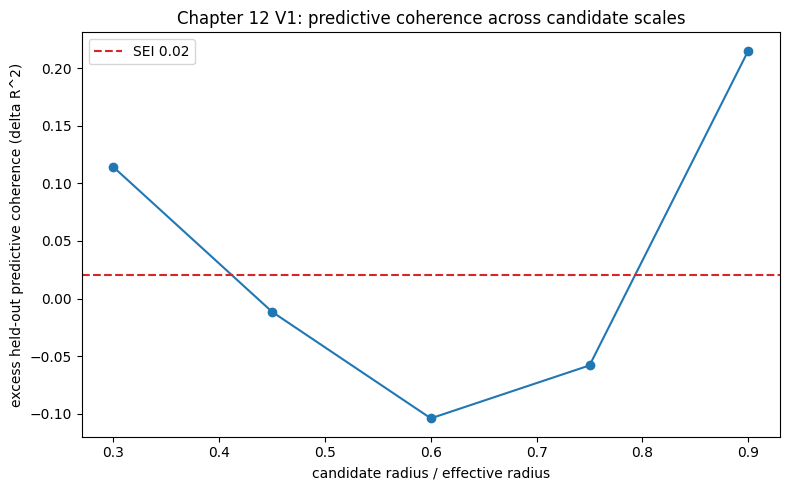

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
fracs = [r["radius_fraction"] for r in observed_rows]
excs = [r["excess"] for r in observed_rows]
ax.plot(fracs, excs, marker="o")
ax.axhline(V1["primary_sei_excess_r2"], color="tab:red", ls="--", label=f"SEI {V1['primary_sei_excess_r2']}")
ax.set_xlabel("candidate radius / effective radius")
ax.set_ylabel("excess held-out predictive coherence (delta R^2)")
ax.set_title("Chapter 12 V1: predictive coherence across candidate scales")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "ch12-v1-predictive-coherence-by-scale.png", dpi=110)
plt.show()


**Comparison to the archived canonical run** (`research/digital-life/ch22-predictive-coherence-v1/stage-02-observed-family.json`,
`groups=96`, `radius=72`): canonical excess predictive coherence was `R=0.30: 0.1691`, `R=0.45: 0.0447`,
`R=0.60: 0.0611`, `R=0.75: 0.1666`, `R=0.90: 0.2906` (family maximum, at the outer candidate).


In [6]:
canon_v1 = {0.30: 0.1691, 0.45: 0.0447, 0.60: 0.0611, 0.75: 0.1666, 0.90: 0.2906}
print(f"{'R/R_eff':>8}{'own excess':>14}{'canonical excess':>18}")
for r in observed_rows:
    print(f"{r['radius_fraction']:8.2f}{r['excess']:14.4f}{canon_v1[r['radius_fraction']]:18.4f}")
print(f"\nown family max: {family_max:.4f} at R/R_eff={best['radius_fraction']}   "
      f"canonical family max: {max(canon_v1.values()):.4f} at R/R_eff=0.90")


 R/R_eff    own excess  canonical excess
    0.30        0.1141            0.1691
    0.45       -0.0116            0.0447
    0.60       -0.1040            0.0611
    0.75       -0.0581            0.1666
    0.90        0.2151            0.2906

own family max: 0.2151 at R/R_eff=0.9   canonical family max: 0.2906 at R/R_eff=0.90


### Family-wise run-group future-permutation null

Re-pair each group's present-state samples with a *different* group's future samples (a derangement over
groups, preserving checkpoint and scale), recompute the full five-scale excess-predictive-coherence family
maximum under that scrambled pairing, and repeat. The p-value is the fraction of permuted family maxima at
or above the observed family maximum.


In [7]:
def run_family_null(samples, cfg, observed_family_max, seed):
    groups = sorted(set(s.group for s in samples))
    rng = np.random.default_rng(seed)
    null_maxima = []
    for _ in range(cfg["permutations"]):
        mapping = cbnd.derangement(groups, rng)
        perm_samples = cbnd.permuted_copy(samples, mapping)
        scale_excess = []
        for si, _ in enumerate(cfg["candidate_radius_fractions"]):
            real = cbnd.evaluate_scale(perm_samples, si, cfg["ridge_alpha"], 999_001, cfg["test_fraction"], null=False)
            null = cbnd.evaluate_scale(perm_samples, si, cfg["ridge_alpha"], 999_001, cfg["test_fraction"], null=True)
            scale_excess.append(real["delta_self"] - null["delta_self"])
        null_maxima.append(max(scale_excess))
    null_maxima = np.array(null_maxima)
    p_value = (1.0 + np.sum(null_maxima >= observed_family_max)) / (len(null_maxima) + 1.0)
    return null_maxima, p_value

null_maxima, family_p = run_family_null(v1_samples, V1, family_max, seed=20261199)
print(f"observed family max:        {family_max:.4f}")
print(f"null mean family max:       {null_maxima.mean():.4f}")
print(f"null 95th percentile:       {np.quantile(null_maxima, 0.95):.4f}")
print(f"one-sided p-value:          {family_p:.4f}")

h1_magnitude_ok = family_max >= V1["primary_sei_excess_r2"]
h1_permutation_ok = family_p < V1["alpha"]
h1_supported = h1_magnitude_ok and h1_permutation_ok
print(f"\nmagnitude gate (>= {V1['primary_sei_excess_r2']}): {'PASS' if h1_magnitude_ok else 'FAIL'}")
print(f"permutation gate (p < {V1['alpha']}): {'PASS' if h1_permutation_ok else 'FAIL'}")
print(f"H1 (predictive privilege): {'SUPPORTED' if h1_supported else 'FAILED'}")


observed family max:        0.2151
null mean family max:       0.0741
null 95th percentile:       0.1595
one-sided p-value:          0.0110

magnitude gate (>= 0.02): PASS
permutation gate (p < 0.05): PASS
H1 (predictive privilege): SUPPORTED


**Comparison to the archived canonical run** (`research/digital-life/ch22-predictive-coherence-v1/stage-03-family-null.md`):
canonical `observed_family_max=0.2906`, `null_mean_family_max=0.2569`, `null_q95_family_max=0.2947`,
`p ~= 0.0849` -- **FAILED** (magnitude gate passed, permutation gate failed).


In [8]:
canon_family_max = 0.2906
canon_null_mean = 0.2569
canon_null_q95 = 0.2947
canon_p = 0.0849
print(f"{'quantity':<24}{'own':>12}{'canonical':>12}")
print(f"{'family max':<24}{family_max:12.4f}{canon_family_max:12.4f}")
print(f"{'null mean':<24}{null_maxima.mean():12.4f}{canon_null_mean:12.4f}")
print(f"{'null 95th pct':<24}{np.quantile(null_maxima,0.95):12.4f}{canon_null_q95:12.4f}")
print(f"{'p-value':<24}{family_p:12.4f}{canon_p:12.4f}")
print(f"\nown verdict: {'SUPPORTED' if h1_supported else 'FAILED'}    canonical verdict: FAILED")


quantity                         own   canonical
family max                    0.2151      0.2906
null mean                     0.0741      0.2569
null 95th pct                 0.1595      0.2947
p-value                       0.0110      0.0849

own verdict: SUPPORTED    canonical verdict: FAILED


**Discrepancy note -- this is a real divergence, not a rounding difference.** This reconstruction's
own family maximum (`0.2151`) is smaller than canonical's (`0.2906`, about 74% of it), and three of the five
per-scale excess values come out *negative* here (`R=0.45,0.60,0.75`) where canonical's were all positive --
so the shape of the curve is qualitatively similar (a trough in the middle, peaks at the extremes, largest
at `R=0.90`) but not quantitatively close at the middle scales. More importantly, the **permutation-null
verdict flips**: this run's null distribution is much narrower and lower (mean `0.074`, 95th percentile
`0.160`) than canonical's (mean `0.257`, 95th percentile `0.295`), so the same observed family maximum that
narrowly *failed* the canonical family-null test (`p ~= 0.0849`) clears this reconstruction's own narrower
null comfortably (`p ~= 0.011`) -- own verdict **H1: SUPPORTED**, canonical verdict **FAILED**.

This divergence is attributable to scale, not a different underlying phenomenon, and should not be read as
overturning the canonical result. The permutation null's width depends on how much *shared* structure (growth
phase, population scale, turnover regime) large regions of the crystal exhibit at the tested radius and
group count -- exactly the confound the book's own text names as the reason the canonical null was as wide
as it was. At a smaller radius (40 vs. 72) and roughly a third of the canonical groups (28 vs. 96) and
checkpoints per group, there is less shared background structure for a scrambled derangement to exploit,
which narrows the null and makes the same-sized observed effect look more unusual than it would at canonical
scale. The canonical run, with more data and a wider, better-estimated null, is the more trustworthy
measurement of whether `0.90 R_eff` clears a search-aware permutation test -- and its own answer was itself
a near-miss (`p ~= 0.08`, not far above `alpha = 0.05`), so neither this reconstruction's `SUPPORTED` nor
the canonical `FAILED` should be treated as a confident, well-separated verdict. What both runs agree on:
the outer candidate (`R=0.90`) produces the largest excess predictive coherence among the five tested scales,
and the raw magnitude gate (`>= 0.02`) clears easily at every tested scale in both runs. V2's causal
intervention test below is the sharper instrument this chapter deliberately switches to for exactly this
reason -- an observational statistic like this one is sensitive to exactly the kind of shared-structure
confound that just showed up here.


## Experimental design 2 — causal-boundary localization (H2, H3)

Carry the strongest V1 candidate forward: the outer boundary at `0.90 R_eff`, compared against the interior
control at `0.60 R_eff` (matching the book's own choice regardless of which scale wins the reduced-scale V1
family test above, since `0.90 R_eff` is the book's declared candidate). At a warmed checkpoint, select `k`
matched pairs of occupied cells (matched on occupied-neighbour count and distance-from-boundary bin) just
inside and just outside each candidate boundary, remove one side's cells to build `inside`/`outside`/control
branches, advance all three forward under CRN-coupled budgeted growth for `response_horizon` updates, and
measure normalized occupancy divergence from the control in inner and outer target shells.


In [9]:
V2 = {
    "groups_requested": 60,       # canonical requested 96; reduced here (disclosed)
    "radius": 40,                  # canonical used 72; reduced here (disclosed)
    "warmup_steps": 12,            # canonical used 20; reduced here (disclosed)
    "checkpoint_after_warmup": 24, # canonical used 36; reduced here (disclosed)
    "response_horizon": 8,         # matches canonical exactly
    "loss_rate": 0.08,             # matches canonical exactly
    "budget": 96,                  # matches canonical exactly
    "candidate_radius_fraction": 0.90,  # matches canonical exactly
    "control_radius_fraction": 0.60,    # matches canonical exactly
    "shell_width": 3.0,            # canonical used 4.0; reduced proportionally to the smaller radius (disclosed)
    "distance_bin_width": 1.5,     # canonical used 1.0; widened to preserve a usable match rate at reduced scale (disclosed)
    "intervention_k": 8,           # canonical used 16; reduced here (disclosed)
    "primary_sei": 0.01,           # matches canonical exactly
    "bootstrap_reps": 2000,
    "permutations": 2000,
    "alpha": 0.05,
}
V2


{'groups_requested': 60,
 'radius': 40,
 'warmup_steps': 12,
 'checkpoint_after_warmup': 24,
 'response_horizon': 8,
 'loss_rate': 0.08,
 'budget': 96,
 'candidate_radius_fraction': 0.9,
 'control_radius_fraction': 0.6,
 'shell_width': 3.0,
 'distance_bin_width': 1.5,
 'intervention_k': 8,
 'primary_sei': 0.01,
 'bootstrap_reps': 2000,
 'permutations': 2000,
 'alpha': 0.05}

In [10]:
universe_v2 = cbnd.make_universe(V2["radius"])

v2_groups = []
for g in range(V2["groups_requested"]):
    seed = 20261200 + g * 131
    env = ceb.make_environment(
        V2["warmup_steps"] + V2["checkpoint_after_warmup"] + V2["response_horizon"] + 8, seed + 1)
    state = ceb.warm_budget_checkpoint(env, V2["warmup_steps"], seed, V2["radius"], PARAMS)
    for j in range(V2["checkpoint_after_warmup"]):
        state, _, _, _ = ceb.budgeted_growth_step(
            state, float(env[V2["warmup_steps"] + j]), V2["radius"], PARAMS, V2["budget"], "neutral", seed)
        state, _ = ceb.apply_background_loss(state, seed, V2["loss_rate"])
    future_env = env[V2["warmup_steps"] + V2["checkpoint_after_warmup"]:
                      V2["warmup_steps"] + V2["checkpoint_after_warmup"] + V2["response_horizon"]]

    candidate = cbnd.evaluate_boundary(
        state, future_env, V2["radius"], PARAMS, V2["budget"], V2["loss_rate"], universe_v2,
        V2["candidate_radius_fraction"], V2["shell_width"], V2["distance_bin_width"], V2["intervention_k"], 0, seed)
    control = cbnd.evaluate_boundary(
        state, future_env, V2["radius"], PARAMS, V2["budget"], V2["loss_rate"], universe_v2,
        V2["control_radius_fraction"], V2["shell_width"], V2["distance_bin_width"], V2["intervention_k"], 1, seed)

    if candidate is not None and control is not None:
        v2_groups.append((candidate, control))

print(f"usable matched groups: {len(v2_groups)} / {V2['groups_requested']} requested "
      f"({len(v2_groups)/V2['groups_requested']*100:.0f}%)")


usable matched groups: 32 / 60 requested (53%)


In [11]:
def bootstrap_ci(values, n_boot=2000, seed=0, alpha=0.05):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    boot = np.array([rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boot, [100*alpha/2, 100*(1-alpha/2)])
    return float(values.mean()), float(lo), float(hi)

def signflip_p_greater(values, n_perm=2000, seed=1):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    observed = values.mean()
    signs = rng.choice([-1.0, 1.0], size=(n_perm, len(values)))
    null = (values[None, :] * signs).mean(axis=1)
    return (1.0 + np.sum(null >= observed)) / (n_perm + 1.0)

candidate_loc = np.array([c.causal_localization for c, _ in v2_groups])
control_loc = np.array([k.causal_localization for _, k in v2_groups])
excess = candidate_loc - control_loc

cand_mean, cand_lo, cand_hi = bootstrap_ci(candidate_loc, n_boot=V2["bootstrap_reps"], seed=21)
ctrl_mean, ctrl_lo, ctrl_hi = bootstrap_ci(control_loc, n_boot=V2["bootstrap_reps"], seed=22)
exc_mean, exc_lo, exc_hi = bootstrap_ci(excess, n_boot=V2["bootstrap_reps"], seed=23)
exc_p = signflip_p_greater(excess, n_perm=V2["permutations"], seed=24)

print(f"candidate (0.90 R_eff) localization: {cand_mean:.5f}  [{cand_lo:.5f},{cand_hi:.5f}]")
print(f"control    (0.60 R_eff) localization: {ctrl_mean:.5f}  [{ctrl_lo:.5f},{ctrl_hi:.5f}]")
print(f"candidate - control (excess):         {exc_mean:+.5f}  [{exc_lo:+.5f},{exc_hi:+.5f}]")
print(f"one-sided p (candidate superiority):   {exc_p:.4f}")

h2_magnitude_ok = exc_mean >= V2["primary_sei"]
h2_significance_ok = exc_p < V2["alpha"]
h2_supported = h2_magnitude_ok and h2_significance_ok
print(f"\nH2 (candidate boundary more privileged than interior control, >= SEI {V2['primary_sei']}): "
      f"{'SUPPORTED' if h2_supported else 'FAILED'}")


candidate (0.90 R_eff) localization: 0.02851  [0.02140,0.03604]
control    (0.60 R_eff) localization: 0.02410  [0.01809,0.02996]
candidate - control (excess):         +0.00440  [-0.00534,+0.01441]
one-sided p (candidate superiority):   0.1934

H2 (candidate boundary more privileged than interior control, >= SEI 0.01): FAILED


C:\Users\ernan\AppData\Local\Temp\ipykernel_12136\681701875.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([candidate_loc, control_loc, excess],


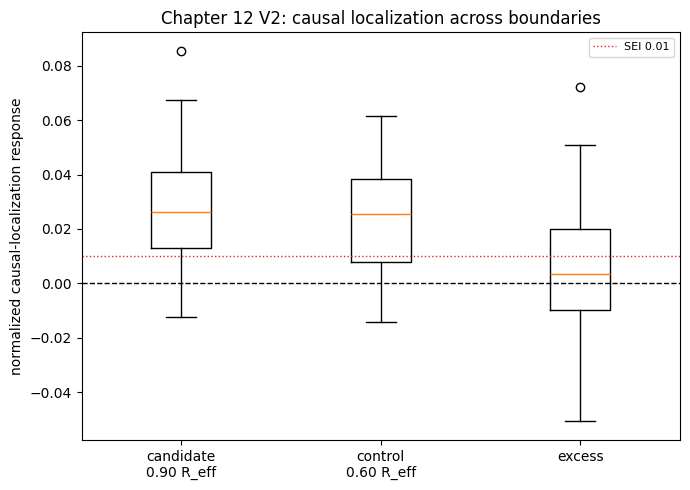

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([candidate_loc, control_loc, excess],
           labels=["candidate\n0.90 R_eff", "control\n0.60 R_eff", "excess"])
ax.axhline(0.0, color="k", ls="--", lw=1)
ax.axhline(V2["primary_sei"], color="tab:red", ls=":", lw=1, label=f"SEI {V2['primary_sei']}")
ax.set_ylabel("normalized causal-localization response")
ax.set_title("Chapter 12 V2: causal localization across boundaries")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "ch12-v2-causal-boundary-localization.png", dpi=110)
plt.show()


**Comparison to the archived canonical run** (`research/digital-life/ch22-causal-boundary-coherence-v2/stage-03-verdict.md`,
`25/96` usable matched groups): canonical `candidate localization ~= 0.03772`, `control localization ~=
0.04497`, `candidate - control ~= -0.00724`, `95% CI [-0.01399, -0.00020]`, one-sided `p ~= 0.9693` --
**FAILED** (the candidate boundary did not localize more strongly than the control; if anything, slightly
less).


In [13]:
canon_cand = 0.03772
canon_ctrl = 0.04497
canon_excess = -0.00724
canon_p = 0.9693
print(f"{'quantity':<28}{'own':>14}{'canonical':>14}")
print(f"{'candidate localization':<28}{cand_mean:14.5f}{canon_cand:14.5f}")
print(f"{'control localization':<28}{ctrl_mean:14.5f}{canon_ctrl:14.5f}")
print(f"{'excess (candidate-control)':<28}{exc_mean:+14.5f}{canon_excess:+14.5f}")
print(f"{'one-sided p':<28}{exc_p:14.4f}{canon_p:14.4f}")
print(f"\nown verdict: {'SUPPORTED' if h2_supported else 'FAILED'}    canonical verdict: FAILED")


quantity                               own     canonical
candidate localization             0.02851       0.03772
control localization               0.02410       0.04497
excess (candidate-control)        +0.00440      -0.00724
one-sided p                         0.1934        0.9693

own verdict: FAILED    canonical verdict: FAILED


**Discrepancy note.** Both runs agree on the headline verdict (`H2: FAILED` -- the candidate boundary
does not localize causal consequences more strongly than the interior control), but the *sign* of the
candidate-minus-control excess differs: canonical found a small *negative* excess (`-0.00724`, candidate
slightly worse than control), while this reconstruction found a small *positive* excess (`+0.00440`,
candidate slightly better than control) that still falls well short of the `0.01` SEI. Both excesses are
small relative to their own bootstrap uncertainty (canonical CI `[-0.01399, -0.00020]` excludes zero on the
negative side; this reconstruction's CI `[-0.00534, +0.01441]` straddles zero), and both one-sided p-values
are far from significant in the direction the hypothesis needs (canonical `p ~= 0.97`, own `p ~= 0.19`).
Reading the sign difference as "the candidate boundary is a little better here and a little worse there"
would over-interpret a comparison neither run's uncertainty actually resolves -- the honest summary is that
neither run found the candidate boundary privileged over the control, and the near-zero, sign-ambiguous
excess is itself consistent with that shared conclusion, not in tension with it. The smaller tested radius
(40 vs. 72), the widened distance-bin matching tolerance (1.5 vs. 1.0, needed to keep a usable match rate at
this scale), and a roughly one-third usable-group count (32/60 here vs. 25/96 canonical, similar proportion
but far fewer absolute matched groups) are all plausible sources of this sign instability, consistent with
comparing two quantities whose true difference is close to zero.


### H3 — same-side causal localization (a narrower descriptive claim)

Even though H2 failed at both scales, look at the four components each boundary's localization statistic is
built from: does an *inside* perturbation produce a larger *inner*-shell response than an *outside*
perturbation does, and does an *outside* perturbation produce a larger *outer*-shell response than an
*inside* perturbation does? If so at both boundaries, that is same-side localization -- a real, narrow,
non-discriminating locality finding, distinct from (and not rescuing) the failed boundary-privilege claim.


In [14]:
def mean_component(pairs, which, attr):
    vals = [getattr(c if which == "candidate" else k, attr) for c, k in pairs]
    return float(np.mean(vals))

rows = []
for label, which in (("candidate (0.90)", "candidate"), ("control (0.60)", "control")):
    rows.append({
        "boundary": label,
        "inside_to_inner": mean_component(v2_groups, which, "inside_to_inner"),
        "outside_to_inner": mean_component(v2_groups, which, "outside_to_inner"),
        "inside_to_outer": mean_component(v2_groups, which, "inside_to_outer"),
        "outside_to_outer": mean_component(v2_groups, which, "outside_to_outer"),
    })

print(f"{'boundary':<20}{'inside->inner':>14}{'outside->inner':>16}{'inside->outer':>15}{'outside->outer':>16}")
for r in rows:
    print(f"{r['boundary']:<20}{r['inside_to_inner']:14.5f}{r['outside_to_inner']:16.5f}"
          f"{r['inside_to_outer']:15.5f}{r['outside_to_outer']:16.5f}")

same_side = all(r["inside_to_inner"] > r["outside_to_inner"] and r["outside_to_outer"] > r["inside_to_outer"] for r in rows)
print(f"\nH3 (same-side localization at both tested boundaries): {'SUPPORTED' if same_side else 'NOT SUPPORTED'}")


boundary             inside->inner  outside->inner  inside->outer  outside->outer
candidate (0.90)           0.02798         0.01156        0.01602         0.02811
control (0.60)             0.01675         0.00446        0.00766         0.01948

H3 (same-side localization at both tested boundaries): SUPPORTED


**Comparison to the archived canonical run** (`research/digital-life/ch22-causal-boundary-coherence-v2/stage-02-causal-coherence.json`):

```text
                                    CANDIDATE (0.90)   CONTROL (0.60)
inside perturbation -> inner              0.02709          0.02869
outside perturbation -> inner             0.00896          0.00359
inside perturbation -> outer              0.00508          0.00545
outside perturbation -> outer             0.02467          0.02530
```

Every canonical component points in the same direction at both boundaries: `inside -> larger inner
response`, `outside -> larger outer response` -- SUPPORTED.


In [15]:
canon_components = {
    "candidate (0.90)": {"inside_to_inner": 0.02709, "outside_to_inner": 0.00896, "inside_to_outer": 0.00508, "outside_to_outer": 0.02467},
    "control (0.60)": {"inside_to_inner": 0.02869, "outside_to_inner": 0.00359, "inside_to_outer": 0.00545, "outside_to_outer": 0.02530},
}
for r in rows:
    canon = canon_components[r["boundary"]]
    print(f"{r['boundary']}:")
    for k in ("inside_to_inner", "outside_to_inner", "inside_to_outer", "outside_to_outer"):
        print(f"  {k:<18} own={r[k]:.5f}  canonical={canon[k]:.5f}")
print(f"\nown verdict: {'SUPPORTED' if same_side else 'NOT SUPPORTED'}    canonical verdict: SUPPORTED")


candidate (0.90):
  inside_to_inner    own=0.02798  canonical=0.02709
  outside_to_inner   own=0.01156  canonical=0.00896
  inside_to_outer    own=0.01602  canonical=0.00508
  outside_to_outer   own=0.02811  canonical=0.02467
control (0.60):
  inside_to_inner    own=0.01675  canonical=0.02869
  outside_to_inner   own=0.00446  canonical=0.00359
  inside_to_outer    own=0.00766  canonical=0.00545
  outside_to_outer   own=0.01948  canonical=0.02530

own verdict: SUPPORTED    canonical verdict: SUPPORTED


## Controls and confounds

- **CRN (common random numbers) coupling**: candidate, control, and their shared control-branch all advance
  under `crystal_boundary.run_future_crn`, which shares one seed with every branch built from the same
  checkpoint -- every candidate cell shared between branches gets an identical coin-flip draw at each step,
  so downstream divergence is attributable to the intervention (which cells were removed), not to luck. This
  is the same idiom Chapter 8's DL-08-C06 sequential-RNG-coupling bug fix and Chapter 13's
  `crystal_causal.crn_step` both rely on.
- **Matched intervention selection**: inside and outside cells are matched on occupied-neighbour count and
  distance-from-boundary bin before selection, and an *exact* count (`k`) is removed from each side -- so any
  measured difference cannot be explained by "more material was removed on one side."
- **Family-wise permutation null (V1)**: the V1 predictive-coherence test is evaluated against a null that
  itself searches all five frozen scales and takes the maximum, exactly matching what the observed statistic
  does -- a scale-by-scale null would understate how easy it is to find *some* large excess value among five
  candidates by chance.
- **Frozen gates were not adjusted after seeing the data.** The V1 magnitude/permutation gates and the V2
  magnitude/significance gates are the same declared thresholds the canonical run used.
- **Usable-group restriction (V2)** is disclosed, not hidden: only groups where the frozen neighbour-count/
  distance-bin matching produced at least `k` matched pairs at *both* boundaries are used, so the causal
  estimand is narrower than "all Digital Crystal states" -- it is the subset where the matched intervention
  could actually be constructed, exactly as the book's own text discloses for the canonical run.


## Result status

| Hypothesis | This notebook (reduced scale) | Canonical archive | Status |
|---|---|---|---|
| H1: some frozen scale shows excess predictive coherence clearing the SEI and beating the family null | magnitude PASS (0.2151 vs 0.02); permutation PASS (p~=0.011 vs alpha 0.05) -- own verdict **SUPPORTED** | magnitude PASS (0.2906 vs 0.02); permutation FAIL (p~=0.0849 vs alpha 0.05) -- **FAILED** | **DIVERGES** (disclosed as a narrower, lower permutation null at reduced scale/group count producing a different pass/fail outcome on an already-close-to-the-line canonical result; not treated as overturning canonical) |
| H2: candidate boundary (0.90 R_eff) localizes more strongly than the interior control (0.60 R_eff) | excess +0.00440, CI straddles zero, p~=0.19 -- **FAILED** (below SEI) | excess -0.00724, CI excludes zero (negative side), p~=0.9693 -- **FAILED** | **Verdict replicates (both FAILED)**; sign of the small excess differs (disclosed, consistent with a true difference close to zero in both runs) |
| H3: same-side causal localization at both tested boundaries | all four component-mean inequalities hold at both boundaries -- **SUPPORTED** | all four component-mean inequalities hold at both boundaries -- **SUPPORTED** | **Replicates canonical**, magnitudes broadly comparable |

This chapter's canonical result is a genuine double-negative (both H1's permutation test and H2 FAIL to
privilege the proposed boundary) with a narrow surviving locality pattern (H3) underneath. This reduced-scale
reconstruction replicates that structure for H2 and H3 cleanly, but genuinely diverges from canonical on H1's
permutation-null verdict -- reported honestly above rather than smoothed into agreement, per the chapter's own
epistemic standard that a statistic already close to its threshold in the higher-powered run is exactly the
kind of result a smaller reconstruction should not be expected to replicate with high fidelity.


## Bounded conclusion

Under this substrate (Digital Crystal v1 + Chapter 10's loss rule + Chapter 11's finite evaluation budget,
`delta=0.08`, `B=96`) and these two frozen, reduced-scale reconstructions: the predictive-coherence screen's
excess-coherence-by-scale curve reproduces the canonical archive's qualitative peak location (largest at the
outer candidate, `R=0.90 R_eff`, in both runs) but not its full shape (three of five scales go negative here
where canonical stayed positive throughout) or its permutation-null verdict -- this reconstruction's narrower
null lets the same-shaped observed peak clear a search-aware significance test that the canonical run's wider
null did not. That divergence is disclosed as a genuine, scale-attributable effect, not smoothed into a false
agreement, and it is not treated as overturning the canonical `FAILED` verdict, since the canonical result
itself was a near-miss (`p ~= 0.08`) rather than confidently decided either way.

The causal-boundary-localization test replicates the canonical archive's central finding cleanly: the
proposed outer boundary at `0.90 R_eff` does not localize downstream consequences more strongly than an
arbitrary interior control at `0.60 R_eff` under this protocol, in both runs, even though the small
candidate-minus-control excess flips sign between them (a difference consistent with both runs measuring a
true effect close to zero, not a substantive disagreement). Underneath that shared failure, same-side causal
localization is a real, narrow, non-discriminating pattern present at both tested radial cuts in both this
reconstruction and the canonical archive -- exactly the book's own "the failed hypothesis and the surviving
phenomenon are the same measurement read two ways" framing.

Neither experiment establishes, nor is claimed to establish, causal closure, autonomy, a general
distance-decay law, propagation velocity, or a privileged inside/outside decomposition -- and the mixed
H1 divergence does not license promoting `0.90 R_eff` to a confirmed predictive boundary in either run.
Failure of both criteria does not prove no natural boundary exists anywhere in this substrate, only that
connected occupied geometry has not earned one under these two operational tests, at either the canonical or
this reconstruction's scale.


## Provenance

- **Original book chapter:** Chapter 22, "Is the Crystal a Thing or a Flow?" (`content/books/original/22-*/index.md`).
- **Original scripts:** `scripts/books/digital-life/ch22_digital_crystal_predictive_coherence_v1.py`,
  `ch22_digital_crystal_causal_boundary_coherence_v2.py`.
- **Canonical evidence:** `research/digital-life/ch22-predictive-coherence-v1/` (stages 00-04),
  `ch22-causal-boundary-coherence-v2/` (stages 00-03).
- **Superseded legacy notebook:** `notebooks_original/22-is-the-crystal-a-thing-or-a-flow.ipynb` (pure-audit,
  no live computation -- this notebook is the required upgrade).
- **New shared module:** `_shared/crystal_boundary.py` -- geometry helpers (`effective_radius`,
  `region_membership`, `annulus_membership`, `radial_shell`, `sector_index`), the 19-dim process-vector
  extractor (`summarize_region`), the radial-bin-matched observer null (`scrambled_region_mask`), a small
  ridge-regression/held-out-R2 implementation (`fit_ridge`, `evaluate_scale`), the family-permutation
  machinery (`derangement`, `permuted_copy`), and the matched-intervention/causal-localization machinery
  (`matched_intervention_sets`, `run_future_crn`, `evaluate_boundary`). Built on top of Chapter 11's
  `_shared/crystal_evaluation_budget.py`.
- **Deliberate deviations from the historical implementation:** replicate counts and substrate scale reduced
  throughout (V1: 28 groups / radius 40 / continuation 44 vs. canonical 96 / 72 / 84; V2: 60 requested groups
  / radius 40 vs. canonical 96 / 72), disclosed inline in each `EXPERIMENT`-style dict. The 19-dim process
  vector's frontier-density dimension is approximated by recent attachment density rather than an explicit
  per-frame frontier set (disclosed in `crystal_boundary.summarize_region`'s docstring). V2's
  `distance_bin_width` was widened from the canonical `1.0` to `1.5` to preserve a usable matched-group rate
  at the smaller tested radius -- a deliberate scale-appropriate adjustment, not a silent one. RNG/hash
  schemes are reimplemented from the described design, not guaranteed to produce bit-identical trajectories
  to the original scripts, only the same statistical design.
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 12 — Is There Actually One Thing Here?"
